# Project: Text Analytics for Business Insight
### SC 663 402 Data Warehouse and Big Data Analytics

**นายอพิชัย อิ่มวงค์ รหัส 673020269-7**

### กติกาการทำงาน

1. Notebook ที่ส่งต้องรันได้ตามลำดับและมีผลลัพธ์ที่จำเป็นต่อการตรวจ หากแยก Part 2/3 เป็นสองไฟล์ แต่ละไฟล์ต้องมี setup/path ที่ชัดเจน
2. ประกาศ `RANDOM_SEED` และ `SAMPLE_N` ไว้ในเซลล์ setup และใช้ค่าเดียวกันตลอดการวิเคราะห์ที่เกี่ยวข้อง
3. ห้ามสรุป insight จาก word cloud เพียงอย่างเดียว ทุกข้อสรุปต้องมีตัวเลข หลักฐาน หรือการเปรียบเทียบรองรับ
4. Part 1 เป็นงานเดี่ยวและทุกคนต้องส่งเอง ส่วน Part 2–3 เป็นงานกลุ่มและส่งโดยตัวแทนทีมเพียง 1 คน
5. Part 3 ต้องใช้ **โปรแกรมอัตโนมัติในการเก็บข้อมูล** เช่น API client, RSS collector หรือ Web Robot/Crawler ห้ามเก็บ 200 valid recordsด้วยการ copy-paste ด้วยมือ
6. การเก็บข้อมูลออนไลน์ต้องเคารพ `robots.txt`, rate limit, Terms of Service/เงื่อนไขของเว็บไซต์, ลิขสิทธิ์ และ PDPA ห้าม bypass login, CAPTCHA, paywall หรือระบบป้องกันการเข้าถึง
7. ใช้ AI ช่วยได้ แต่ต้องมีสไลด์ AI usage ระบุว่าใช้ทำอะไร และทีมตรวจสอบความถูกต้องอย่างไร
8. ทุกคนต้องอธิบาย **ส่วนที่ตนรับผิดชอบ** ได้ในวันนำเสนอ และควรเข้าใจว่าผลงานส่วนนั้นเชื่อมกับข้อสรุปของทีมอย่างไร


In [1]:
"""
หากยังไม่มี library ใด ให้ติดตั้งก่อน
!pip install -q nltk wordcloud scikit-learn pandas matplotlib tqdm huggingface_hub
!pip install -q pythainlp          # ใช้เมื่อทำงานกับข้อความภาษาไทย
"""
import json, os, re, random, itertools, time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
for pkg in ["punkt_tab", "stopwords", "wordnet", "vader_lexicon"]:
    nltk.download(pkg, quiet=True)

%matplotlib inline

RANDOM_SEED = 42
SAMPLE_N = 20_000         # เวอร์ชันลด workload: Part 2 ใช้อย่างน้อย 20,000 รีวิว
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DATA_DIR = "./data/"
os.makedirs(DATA_DIR, exist_ok=True)

---
# Part 1: Social Listening Warm-up
*งานเดี่ยว — ทุกคนต้องทำและส่งของตนเอง ไม่ต้องนำเสนอ (10 คะแนน)*

ใช้ข้อมูลโพสต์สาธารณะจาก **Bluesky**  
https://huggingface.co/datasets/alpindale/two-million-bluesky-posts

ใช้เพียง **1–3 ไฟล์** ก็พอ ไม่จำเป็นต้องโหลดทั้ง dataset

ฟิลด์ที่มี เช่น `text`, `created_at`, `author`, `uri`, `has_images`, `reply_to`, `predicted_language`

## ตอบ 4 คำถามหลัก

1. **คนโพสต์เมื่อไร:** จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด
2. **ใช้ภาษาอะไร:** รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด
3. **คนพูดถึงอะไร:** หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ
4. **ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้:** สร้าง visualization 1 รูป แล้วเขียนข้อจำกัด 3–5 บรรทัด

> Part 1 เป็น warm-up ไม่ต้องทำ influencer analysis หรือ reply-network เว้นแต่สนใจทำเพิ่มเอง


posts_20241127_075347.jsonl:   0%|          | 0.00/2.72M [00:00<?, ?B/s]

posts_20241127_122447.jsonl: reconstructing file:   0%|          |  0.00B / 39.3MB            

posts_20241127_122447.jsonl: downloading bytes:           |  0.00B            

posts_20241127_153954.jsonl:   0%|          | 0.00/263k [00:00<?, ?B/s]

ไฟล์ที่ใช้วิเคราะห์:
 - posts_20241127_075347.jsonl
 - posts_20241127_122447.jsonl
 - posts_20241127_153954.jsonl

สรุปชุดข้อมูล
จำนวน records ในไฟล์ที่เลือกทั้งหมด: 107,530
จำนวน posts ที่มีข้อความ: 103,927
จำนวน posts ที่สุ่มมาใช้วิเคราะห์: 19,328
ช่วงเวลา: 2008-04-15 22:19:57+00:00 ถึง 2024-11-28 01:28:07.009819+00:00

[Q1] เวลาโพสต์
- จำนวน posts ในไฟล์ที่เลือก: 107,530
- ช่วงเวลา: 2008-04-15 22:19:57+00:00 ถึง 2024-11-28 01:28:07.009819+00:00
- ชั่วโมงที่มีโพสต์มากที่สุด (UTC): 12:00 จำนวน 94,444 posts

[Q2] ภาษา
- วิธีระบุภาษา: langdetect fallback


...

,word,count
0,de,1958
1,que,1103
2,la,925
3,like,744
4,en,713
5,one,605
6,good,585
7,com,554
8,get,510
9,people,454


[Q3] วลี 2 คำเด่น


,phrase,count
0,de la,174
1,good morning,161
2,bsky app,74
3,app profile,66
4,en la,53
5,en el,48
6,open spotify,46
7,spotify com,46
8,youtube com,43
9,stayed influenced,43


[Q3] ตัวอย่างข้อความจริง


,hashtag,example_text
0,#art,Reflecting on the fear during Trump’s first te...
1,#art,I just finished this Christmas-themed illustra...
2,#Bettencourt,"""La diff. des enregistrements a porté à la con..."
3,#Bettencourt,"""Quelle connaissance aviez-vous de l'existence..."
4,#eduinov,"#eduinov le Livret du participant, 100 p. déco..."
5,#eduinov,#eduinov STENCIL : Réseau Eurd’Enseign des Sci...
6,#BookSky,Choose 20 books that have stayed with you or i...
7,#BookSky,Choose 20 books that have stayed with you or i...
8,#BookChallenge,Choose 20 books that have stayed with you or i...
9,#BookChallenge,Choose 20 books that have stayed with you or i...


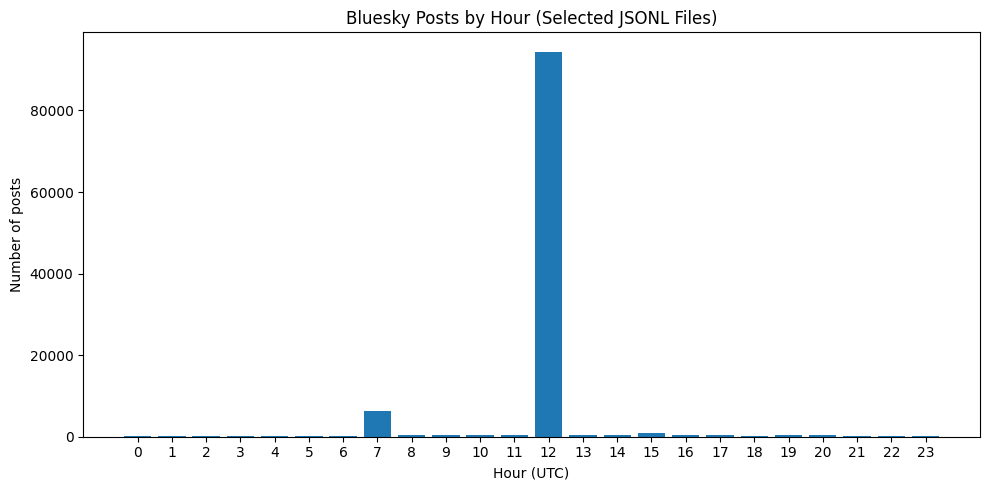

[Q4] ข้อจำกัดของข้อมูล
1. วิเคราะห์จากไฟล์ที่เลือกเพียง 3 ไฟล์ ไม่ใช่ข้อมูลทั้งหมด 2.1 ล้านโพสต์
2. การวิเคราะห์ภาษาและคำ/วลีใช้ตัวอย่างแบบสุ่ม 19,328 โพสต์ จึงอาจต่างจากภาพรวมทั้งชุด
3. ข้อมูลเป็นโพสต์สาธารณะจาก Bluesky ช่วงเวลาหนึ่ง จึงไม่ควรสรุปแทนผู้ใช้โซเชียลทั้งหมด
4. เวลาในข้อมูลเป็น UTC และการระบุภาษาอาจมีความคลาดเคลื่อน โดยเฉพาะข้อความสั้น หลายภาษา หรือมี emoji/URL จำนวนมาก
5. Hashtag/คำเด่นบอกสิ่งที่ถูกพูดถึงบ่อย แต่ไม่เพียงพอที่จะสรุปความรู้สึกหรือเหตุและผลของพฤติกรรมผู้ใช้


In [2]:
# ----------------- Your code here -----------------
# ใบ้: อ่าน JSON lines ทีละบรรทัดด้วย generator ไม่ต้องโหลดทั้งไฟล์
# def iter_jsonl(path):
#     with open(path, encoding='utf-8') as f:
#         for line in f:
#             yield json.loads(line)
# ----------------- Part 1: Complete solution -----------------
# โค้ดนี้เลือก JSONL เพียง 1–3 ไฟล์ และสุ่มแบบ reproducible ด้วย RANDOM_SEED
# เพื่อไม่ต้องโหลด dataset ทั้ง 2 ล้านโพสต์เข้าหน่วยความจำ

from pathlib import Path
from collections import Counter
import glob
import unicodedata

from huggingface_hub import list_repo_files, hf_hub_download

REPO_ID = "alpindale/two-million-bluesky-posts"
MAX_FILES = 3

def iter_jsonl(path):
    """อ่าน JSONL แบบทีละบรรทัด ไม่โหลดทั้งไฟล์เข้าหน่วยความจำ"""
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    yield json.loads(line)
                except json.JSONDecodeError:
                    continue

def choose_jsonl_files():
    local_files = sorted(str(p) for p in Path(DATA_DIR).glob("*.jsonl"))
    if local_files:
        # เลือก 1–3 ไฟล์ที่กระจายตามช่วงเวลา: ต้น/กลาง/ท้าย
        n = min(MAX_FILES, len(local_files))
        if n == 1:
            return local_files
        if n == 2:
            idx = [0, len(local_files)-1]
        else:
            idx = [0, len(local_files)//2, len(local_files)-1]
        return [local_files[i] for i in idx]

    repo_files = sorted(
        f for f in list_repo_files(REPO_ID, repo_type="dataset")
        if f.endswith(".jsonl")
    )
    if not repo_files:
        raise FileNotFoundError("ไม่พบไฟล์ .jsonl ใน dataset")

    n = min(MAX_FILES, len(repo_files))
    if n == 1:
        chosen = repo_files
    elif n == 2:
        chosen = [repo_files[0], repo_files[-1]]
    else:
        chosen = [repo_files[0], repo_files[len(repo_files)//2], repo_files[-1]]

    paths = []
    for fname in chosen:
        paths.append(
            hf_hub_download(
                repo_id=REPO_ID,
                filename=fname,
                repo_type="dataset",
                local_dir=DATA_DIR
            )
        )
    return paths

selected_files = choose_jsonl_files()

print("ไฟล์ที่ใช้วิเคราะห์:")
for p in selected_files:
    print(" -", Path(p).name)

# ---------- อ่านข้อมูลแบบ streaming + reservoir sampling ----------
def collect_data(paths, sample_n):
    reservoir = []
    total_records = 0
    valid_text_records = 0
    hourly_counts = Counter()
    min_dt, max_dt = None, None

    for path in paths:
        for row in iter_jsonl(path):
            total_records += 1

            dt = pd.to_datetime(row.get("created_at"), utc=True, errors="coerce")
            if pd.notna(dt):
                min_dt = dt if min_dt is None else min(min_dt, dt)
                max_dt = dt if max_dt is None else max(max_dt, dt)
                hourly_counts[int(dt.hour)] += 1

            text = row.get("text")
            if isinstance(text, str) and text.strip():
                valid_text_records += 1

            # Reservoir sampling: สุ่มให้ได้ SAMPLE_N โดยไม่ bias ตามลำดับไฟล์
            if len(reservoir) < sample_n:
                reservoir.append(row)
            else:
                j = random.randrange(total_records)
                if j < sample_n:
                    reservoir[j] = row

    return pd.DataFrame(reservoir), total_records, valid_text_records, hourly_counts, min_dt, max_dt

sample_df, total_records, valid_text_records, hourly_counts, min_dt, max_dt = collect_data(
    selected_files, SAMPLE_N
)

# ทำความสะอาดข้อมูลสำหรับการวิเคราะห์ข้อความ
df = sample_df.copy()
df["text"] = df["text"].fillna("").astype(str)
df["created_at"] = pd.to_datetime(df["created_at"], utc=True, errors="coerce")
df = df[df["text"].str.strip().ne("")].copy()

print("\nสรุปชุดข้อมูล")
print(f"จำนวน records ในไฟล์ที่เลือกทั้งหมด: {total_records:,}")
print(f"จำนวน posts ที่มีข้อความ: {valid_text_records:,}")
print(f"จำนวน posts ที่สุ่มมาใช้วิเคราะห์: {len(df):,}")
print(f"ช่วงเวลา: {min_dt} ถึง {max_dt}")

# ---------- Q1 คนโพสต์เมื่อไร ----------
hourly_df = (
    pd.Series(hourly_counts, name="post_count")
    .rename_axis("hour_utc")
    .reset_index()
    .sort_values("hour_utc")
)

peak_hour = int(hourly_df.loc[hourly_df["post_count"].idxmax(), "hour_utc"])
peak_count = int(hourly_df["post_count"].max())

print("\n[Q1] เวลาโพสต์")
print(f"- จำนวน posts ในไฟล์ที่เลือก: {total_records:,}")
print(f"- ช่วงเวลา: {min_dt} ถึง {max_dt}")
print(f"- ชั่วโมงที่มีโพสต์มากที่สุด (UTC): {peak_hour:02d}:00 จำนวน {peak_count:,} posts")

# ---------- Q2 ภาษา ----------
# ใช้ predicted_language ถ้ามีในไฟล์
# ถ้าไฟล์ที่ดาวน์โหลดไม่มี field นี้ จะ fallback เป็น langdetect
language_method = None

if "predicted_language" in df.columns:
    language_method = "dataset predicted_language"
    lang_series = df["predicted_language"].fillna("unknown").replace("", "unknown")
else:
    language_method = "langdetect fallback"
    try:
        from langdetect import detect, DetectorFactory
        DetectorFactory.seed = RANDOM_SEED

        def detect_language(text):
            try:
                return detect(text)
            except Exception:
                return "unknown"

        lang_series = df["text"].map(detect_language)
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "langdetect"])
        from langdetect import detect, DetectorFactory
        DetectorFactory.seed = RANDOM_SEED

        def detect_language(text):
            try:
                return detect(text)
            except Exception:
                return "unknown"

        lang_series = df["text"].map(detect_language)

language_pct = (lang_series.value_counts(normalize=True) * 100).round(2)
language_count = lang_series.value_counts()

language_summary = pd.DataFrame({
    "count": language_count,
    "pct": language_pct
}).reset_index(names="language")

print("\n[Q2] ภาษา")
print(f"- วิธีระบุภาษา: {language_method}")
display(language_summary.head(10))

# ---------- Q3 Hashtag / คำเด่น / วลี ----------
hashtag_pattern = re.compile(r"(?<!\w)#([^\s#.,!?;:()\[\]{}<>\"']+)", flags=re.UNICODE)

hashtags = []
for text in df["text"]:
    found = hashtag_pattern.findall(text)
    hashtags.extend("#" + h.rstrip("#") for h in found)

hashtag_counts = Counter(hashtags)
top_hashtags = pd.DataFrame(
    hashtag_counts.most_common(10),
    columns=["hashtag", "count"]
)

# token แบบง่าย: ตัด URL/mention/hashtag ออก และเก็บคำที่ยาวอย่างน้อย 2 ตัวอักษร
stop_words = set()
try:
    stop_words.update(nltk.corpus.stopwords.words("english"))
except Exception:
    pass

def normalize_text(text):
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[@#]\S+", " ", text)
    text = unicodedata.normalize("NFKC", text)
    return text.lower()

word_counter = Counter()
phrase_counter = Counter()

for text in df["text"]:
    cleaned = normalize_text(text)
    tokens = re.findall(r"[^\W\d_]{2,}|[\u0E00-\u0E7F]{2,}", cleaned, flags=re.UNICODE)
    tokens = [t for t in tokens if t not in stop_words]
    word_counter.update(tokens)

    bigrams = zip(tokens, tokens[1:])
    phrase_counter.update(" ".join(bg) for bg in bigrams)

top_words = pd.DataFrame(word_counter.most_common(10), columns=["word", "count"])
top_phrases = pd.DataFrame(phrase_counter.most_common(10), columns=["phrase", "count"])

print("\n[Q3] Hashtag เด่น")
display(top_hashtags)

print("[Q3] คำเด่น")
display(top_words)

print("[Q3] วลี 2 คำเด่น")
display(top_phrases)

# ตัวอย่างข้อความจริงจาก hashtag ที่ติดอันดับ
examples = []
for tag in top_hashtags["hashtag"].head(5):
    mask = df["text"].str.contains(re.escape(tag), case=False, regex=True, na=False)
    for text in df.loc[mask, "text"].head(2):
        examples.append({"hashtag": tag, "example_text": text})

examples_df = pd.DataFrame(examples)
print("[Q3] ตัวอย่างข้อความจริง")
display(examples_df)

# ---------- Q4 Visualization ----------
plot_df = hourly_df.copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["hour_utc"], plot_df["post_count"])
plt.xticks(range(24))
plt.xlabel("Hour (UTC)")
plt.ylabel("Number of posts")
plt.title("Bluesky Posts by Hour (Selected JSONL Files)")
plt.tight_layout()
plt.show()

print("[Q4] ข้อจำกัดของข้อมูล")
limitations = [
    f"1. วิเคราะห์จากไฟล์ที่เลือกเพียง {len(selected_files)} ไฟล์ ไม่ใช่ข้อมูลทั้งหมด 2.1 ล้านโพสต์",
    f"2. การวิเคราะห์ภาษาและคำ/วลีใช้ตัวอย่างแบบสุ่ม {len(df):,} โพสต์ จึงอาจต่างจากภาพรวมทั้งชุด",
    "3. ข้อมูลเป็นโพสต์สาธารณะจาก Bluesky ช่วงเวลาหนึ่ง จึงไม่ควรสรุปแทนผู้ใช้โซเชียลทั้งหมด",
    "4. เวลาในข้อมูลเป็น UTC และการระบุภาษาอาจมีความคลาดเคลื่อน โดยเฉพาะข้อความสั้น หลายภาษา หรือมี emoji/URL จำนวนมาก",
    "5. Hashtag/คำเด่นบอกสิ่งที่ถูกพูดถึงบ่อย แต่ไม่เพียงพอที่จะสรุปความรู้สึกหรือเหตุและผลของพฤติกรรมผู้ใช้"
]
for line in limitations:
    print(line)

# เก็บค่าที่ใช้ในสรุปให้ cell ต่อไปใช้งานได้
top_language = language_summary.iloc[0]["language"] if not language_summary.empty else "ไม่พบข้อมูล"
top_language_pct = language_summary.iloc[0]["pct"] if not language_summary.empty else 0
top_tag = top_hashtags.iloc[0]["hashtag"] if not top_hashtags.empty else "ไม่พบ hashtag"
top_tag_count = int(top_hashtags.iloc[0]["count"]) if not top_hashtags.empty else 0


###**คำอธิบายการวิเคราะห์**

**Q1: คนโพสต์เมื่อไร**  
วิเคราะห์จาก `created_at` โดยแปลงเป็น datetime และนับจำนวนโพสต์ตามชั่วโมง เพื่อหาชั่วโมงที่มีการโพสต์มากที่สุด รวมถึงหาช่วงเวลาเริ่มต้นและสิ้นสุดของข้อมูลที่เลือก

**Q2: ใช้ภาษาอะไร**  
ถ้ามีคอลัมน์ `predicted_language` จะใช้ค่าจาก dataset โดยตรงและคำนวณสัดส่วนของแต่ละภาษา หากไฟล์ที่เลือกไม่มีคอลัมน์นี้ โค้ดจะใช้ `langdetect` เป็นวิธีสำรอง การรายงานควรดูทั้งจำนวนและร้อยละ ไม่ควรดูเฉพาะจำนวน

**Q3: คนพูดถึงอะไร**  
ใช้การนับ `hashtag` และคำ/วลีที่พบบ่อยเพื่อหา topic เบื้องต้น พร้อมดึงข้อความจริงจากข้อมูลมาเป็นตัวอย่างประกอบ เพื่อไม่ให้สรุปจากจำนวนคำหรือ word cloud เพียงอย่างเดียว

**Q4: ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้**  
กราฟแสดงจำนวนโพสต์ตามชั่วโมงเพื่อมองรูปแบบการใช้งานในช่วงข้อมูลที่เลือก แต่ข้อมูลจากเพียง 1–3 ไฟล์และช่วงเวลาจำกัดอาจไม่เป็นตัวแทนของผู้ใช้ Bluesky ทั้งหมด อีกทั้งการระบุภาษาและการนับคำอาจมีความคลาดเคลื่อน



In [3]:

# ----------------- สรุปสั้น ๆ ถึงลูกค้า 5 บรรทัด -----------------
from IPython.display import Markdown, display

summary_md = f"""
**สรุปสั้น ๆ ถึงลูกค้า**

1. จากไฟล์ Bluesky ที่เลือก {len(selected_files)} ไฟล์ พบข้อมูลทั้งหมด **{total_records:,} posts** ครอบคลุมช่วง **{min_dt} ถึง {max_dt} (UTC)**
2. ช่วงเวลาที่มีโพสต์มากที่สุดคือ **{peak_hour:02d}:00 UTC** จำนวนประมาณ **{peak_count:,} posts**
3. ภาษาหลักในตัวอย่างคือ **{top_language}** คิดเป็นประมาณ **{top_language_pct:.2f}%** จึงควรพิจารณาภาษานี้เป็นภาษาหลักในการสื่อสาร
4. ประเด็น/แท็กที่พบเด่นคือ **{top_tag}** จำนวน **{top_tag_count:,} ครั้ง** ซึ่งช่วยบอกหัวข้อที่ผู้ใช้พูดถึงบ่อยในช่วงข้อมูลนี้
5. อย่างไรก็ตาม ผลลัพธ์เป็นภาพจากไฟล์และช่วงเวลาที่เลือก จึงควรใช้เพื่อหาแนวโน้มเบื้องต้น ไม่ควรสรุปแทนผู้ใช้ Bluesky ทั้งหมด
"""
display(Markdown(summary_md))



**สรุปสั้น ๆ ถึงลูกค้า**

1. จากไฟล์ Bluesky ที่เลือก 3 ไฟล์ พบข้อมูลทั้งหมด **107,530 posts** ครอบคลุมช่วง **2008-04-15 22:19:57+00:00 ถึง 2024-11-28 01:28:07.009819+00:00 (UTC)**  
2. ช่วงเวลาที่มีโพสต์มากที่สุดคือ **12:00 UTC** จำนวนประมาณ **94,444 posts**  
3. ภาษาหลักในตัวอย่างคือ **en** คิดเป็นประมาณ **49.52%** จึงควรพิจารณาภาษานี้เป็นภาษาหลักในการสื่อสาร  
4. ประเด็น/แท็กที่พบเด่นคือ **#art** จำนวน **54 ครั้ง** ซึ่งช่วยบอกหัวข้อที่ผู้ใช้พูดถึงบ่อยในช่วงข้อมูลนี้  
5. อย่างไรก็ตาม ผลลัพธ์เป็นภาพจากไฟล์และช่วงเวลาที่เลือก จึงควรใช้เพื่อหาแนวโน้มเบื้องต้น ไม่ควรสรุปแทนผู้ใช้ Bluesky ทั้งหมด


**<สรุปสั้น ๆ ถึงลูกค้า 5 บรรทัด>**

* จากไฟล์ Bluesky ที่เลือก 3 ไฟล์ พบข้อมูลทั้งหมด 107,530 posts ครอบคลุมช่วง 2008-04-15 22:19:57+00:00 ถึง 2024-11-28 01:28:07.009819+00:00 (UTC)
* ช่วงเวลาที่มีโพสต์มากที่สุดคือ 12:00 UTC จำนวนประมาณ 94,444 posts
* ภาษาหลักในตัวอย่างคือ en คิดเป็นประมาณ 49.52% จึงควรพิจารณาภาษานี้เป็นภาษาหลักในการสื่อสาร
* ประเด็น/แท็กที่พบเด่นคือ #art จำนวน 54 ครั้ง ซึ่งช่วยบอกหัวข้อที่ผู้ใช้พูดถึงบ่อยในช่วงข้อมูลนี้
* อย่างไรก็ตาม ผลลัพธ์เป็นภาพจากไฟล์และช่วงเวลาที่เลือก จึงควรใช้เพื่อหาแนวโน้มเบื้องต้น ไม่ควรสรุปแทนผู้ใช้ Bluesky ทั้งหมด